In [1]:
import node2vec
import sys

print(f"Version détectée : {node2vec.__version__}")
print(f"Emplacement physique : {node2vec.__file__}")
print("-" * 30)
print("Ordre de priorité des dossiers (sys.path) :")
for path in sys.path:
    print(path)

Version détectée : 0.5.0
Emplacement physique : /home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/node2vec/__init__.py
------------------------------
Ordre de priorité des dossiers (sys.path) :
/home/jovyan/envs/mon_env_ia/lib/python310.zip
/home/jovyan/envs/mon_env_ia/lib/python3.10
/home/jovyan/envs/mon_env_ia/lib/python3.10/lib-dynload

/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap

import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.loadsave_data_joblib(data=None, filepath = "shap_explainer.joblib", mode="load")

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

✅ Graphe chargé : 3363 nœuds et 13547 liens.


TypeError: loadsave_data_joblib() got an unexpected keyword argument 'filepath'

### Analyse - Pk block_reel_u ne performe pas

In [26]:
list_i = [1.00]

def plot_distributions(df, feature_name="deepwalk_dist"):
        if df is None:
            print("Erreur : Le dataset est vide.")
            return
    
        plt.figure(figsize=(10, 6))
        
        # On filtre les données pour chaque classe de target
        sns.kdeplot(data=df[df['target'] == 0], x=feature_name, label='Target 0 (Pas de lien)', fill=True, alpha=0.5)
        sns.kdeplot(data=df[df['target'] == 1], x=feature_name, label='Target 1 (Lien existant)', fill=True, alpha=0.5)
        
        plt.title(f'Répartition de {feature_name} Distance selon la présence d\'un lien')
        plt.xlabel(feature_name)
        plt.ylabel('Densité')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        
        plt.savefig(f'distrib_{feature_name}.png')
        print(f"Graphique sauvegardé sous 'distrib_{feature_name}.png'")

for i in list_i:
    
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")
    
    G_train, dataset_w_com_and_dist, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph(G_name)

    exclude_cols = ["target", "u", "v", "label", "deepwalk_dist", "deepwalk_cos", "n2v_homophily_dist", "n2v_homophily_cos",
                   "same_infomap", "same_isomap"]
    
    features_to_keep = [c for c in dataset_w_com_and_dist.columns if c not in exclude_cols]
    
    print(f"Réentraînement sans les features de distance...")
    print(f"Features utilisées ({len(features_to_keep)}) : {features_to_keep}")

    metrics, model_no_deepwalk, _, _, _, _ = gp.train_and_eval_xgboost(dataFrame=dataset_w_com_and_dist, features=features_to_keep)

    importances = model_no_deepwalk.feature_importances_
    new_imp_df = pd.DataFrame({'Feature': features_to_keep, 'Importance': importances})
    print("\n--- Nouvelles Importances (Top 10) ---")
    print(new_imp_df.sort_values(by='Importance', ascending=False).head(10))

    """
    cols = ["u", "v", "deepwalk_dist", "target", "block_reel_u", "block_reel_v", 
            , "n2v_homophily_dist", "n2v_homophily_cos"]
    print(dataset_w_com_and_dist[dataset_w_com_and_dist["target"] == 0][cols].head(30)
    
    
    # Appel de la fonction
    plot_distributions(dataset_w_com_and_dist, feature_name = "same_block_reel")

    correlation = dataset_w_com_and_dist['deepwalk_dist'].corr(dataset_w_com_and_dist['same_block_reel'])
    print(f"Corrélation entre DeepWalk et SameBlock: {correlation:.4f}")

    importance_types = ['weight', 'gain', 'cover']
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    model = xgboost_data['model']
    X_train = xgboost_data['X_train']
    booster = model.get_booster()
    
    for i, imp_type in enumerate(importance_types):
        scores = booster.get_score(importance_type=imp_type)
        pd.Series(scores).sort_values().plot(kind='barh', ax=axes[i], title=f'Importance: {imp_type}')
    
    plt.tight_layout()
    plt.savefig('xgboost_validation.png')

    print(dataset_w_com_and_dist["same_block_reel"].value_counts())

    # 2. Vérifiez si elle est bien dans les colonnes envoyées à XGBoost
    print("same_block_reel" in X_train.columns)
    
    # 3. Forcer l'affichage de l'importance même si elle est à zéro
    all_features = X_train.columns
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': all_features, 'Value': importances})
    print(feature_imp_df.sort_values(by='Value', ascending=False))
    """

######################################
#### graph sbm 1.00 pos 0.00 ####
######################################
artificial_graph_sbm_1_00_pos_0_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_1_00_pos_0_00
 Dataset chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 38500 lignes, 33 colonnes.
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Réentraînement sans les features de distance...
Features utilisées (25) : ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'd

### Lancement de calculs sur toutes les sbm ratios

In [ ]:
list_i = [1.00, 0.00]

for i in np.arange(0.00, 1.05, 0.05):
#for i in list_i:
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")

    gp.execute(G,G_name)

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbm_0_00_pos_1_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.
Validation du Graphe terminée. Lancement des calculs...
Graphe original: 3500 liens
Graphe d'entraînement: 2975 liens
Liens cachés pour le test: 525
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/G_train_init_artificial_graph_sbm_0_00_pos_1_00

--- Enrichissement du Graphe avec les Métriques de Structure ---
Calcul : PageRank, Clustering, Average Neighbor Degree, Degree Centrality


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(



--- Enrichissement du Graphe avec les Communautés ---
Calcul des communautés via louvain...
Calcul des communautés via infomap...
Calcul des communautés via sbm...

--- Enrichissement du Graphe avec les Embeddings ---
Calcul des embeddings via n2v_homophily...
Calcul de Node2Vec (p=2, q=0.5)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:05<00:00,  4.86it/s]


Entraînement du modèle Skip-gram...
Calcul des embeddings via deepwalk...
Calcul de Node2Vec (p=1, q=1)...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2): 100%|██████████| 25/25 [00:04<00:00,  6.02it/s]


Entraînement du modèle Skip-gram...


Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_05_pos_0_95.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_10_pos_0_90.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_15_pos_0_85.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_20_pos_0_80.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/re

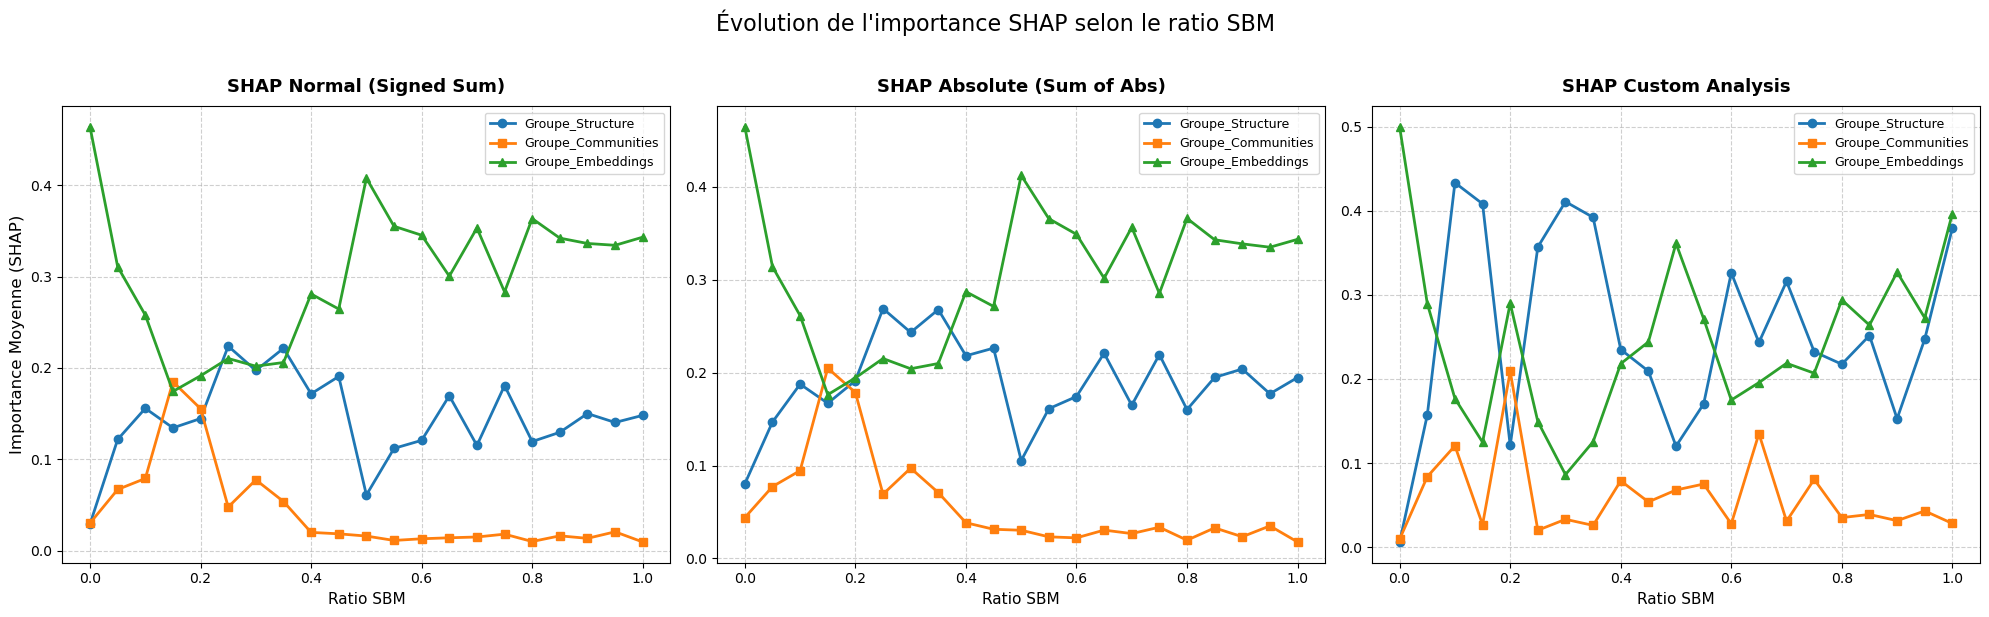

In [13]:
gp.plot_shap_evolution()

In [16]:
import node2vec
import sys

print(f"Version détectée : {node2vec.__version__}")
print(f"Emplacement physique : {node2vec.__file__}")
print("-" * 30)
print("Ordre de priorité des dossiers (sys.path) :")
for path in sys.path:
    print(path)

Version détectée : 0.5.0
Emplacement physique : /home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/node2vec/__init__.py
------------------------------
Ordre de priorité des dossiers (sys.path) :
/home/jovyan/envs/mon_env_ia/lib/python310.zip
/home/jovyan/envs/mon_env_ia/lib/python3.10
/home/jovyan/envs/mon_env_ia/lib/python3.10/lib-dynload

/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages


In [17]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import shap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.loadsave_data_joblib(data=None, filepath = "shap_explainer.joblib", mode="load")

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

✅ Graphe chargé : 3363 nœuds et 13547 liens.


TypeError: loadsave_data_joblib() got an unexpected keyword argument 'filepath'

In [ ]:
for i in np.arange(0, 1, 0.05):
    
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")
            
    gp.execute(G,G_name)

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbm_0_00_pos_1_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.
Validation du Graphe terminée. Lancement des calculs...
Graphe original: 3500 liens
Graphe d'entraînement: 2975 liens
Liens cachés pour le test: 525
Pré-calcul des métriques de nœuds...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


DataFrame créé <3 : 38500 paires de noeuds choisies


--- Calcul des métriques de communauté ---
Calcul des communautés de louvain...
Calcul des communautés via Infomap...
Calcul des communautés via SBM...


--- Calcul des métriques de distance ---
Calcul de Node2Vec homophilie p=2, q=0.5 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:03<00:00,  6.31it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


...

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:04<00:00,  5.52it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2): 100%|██████████| 25/25 [00:04<00:00,  5.56it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Dataset (DataFrame) sauvegardé : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_10_pos_0_90

 RÉSULTATS
[{'F1-Score': 0.96045197740113, 'AUC-ROC': 0.9882997960679348, 'AP': 0.9800314196867739, 'AUC-PR': 0.9800268502964767}]
Sauvegarde des données XGBoost (model,X1yTest et Train)
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_10_pos_0_90.joblib

 RÉSULTATS
 F1-Score  AUC-ROC       AP   AUC-PR
 0.960452   0.9883 0.980031 0.980027

 Shapley va ! Lu.


PermutationExplainer explainer:  59%|█████▉    | 4544/7694 [04:35<03:00, 17.41it/s]

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_05_pos_0_95.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_10_pos_0_90.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_15_pos_0_85.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_20_pos_0_80.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/re

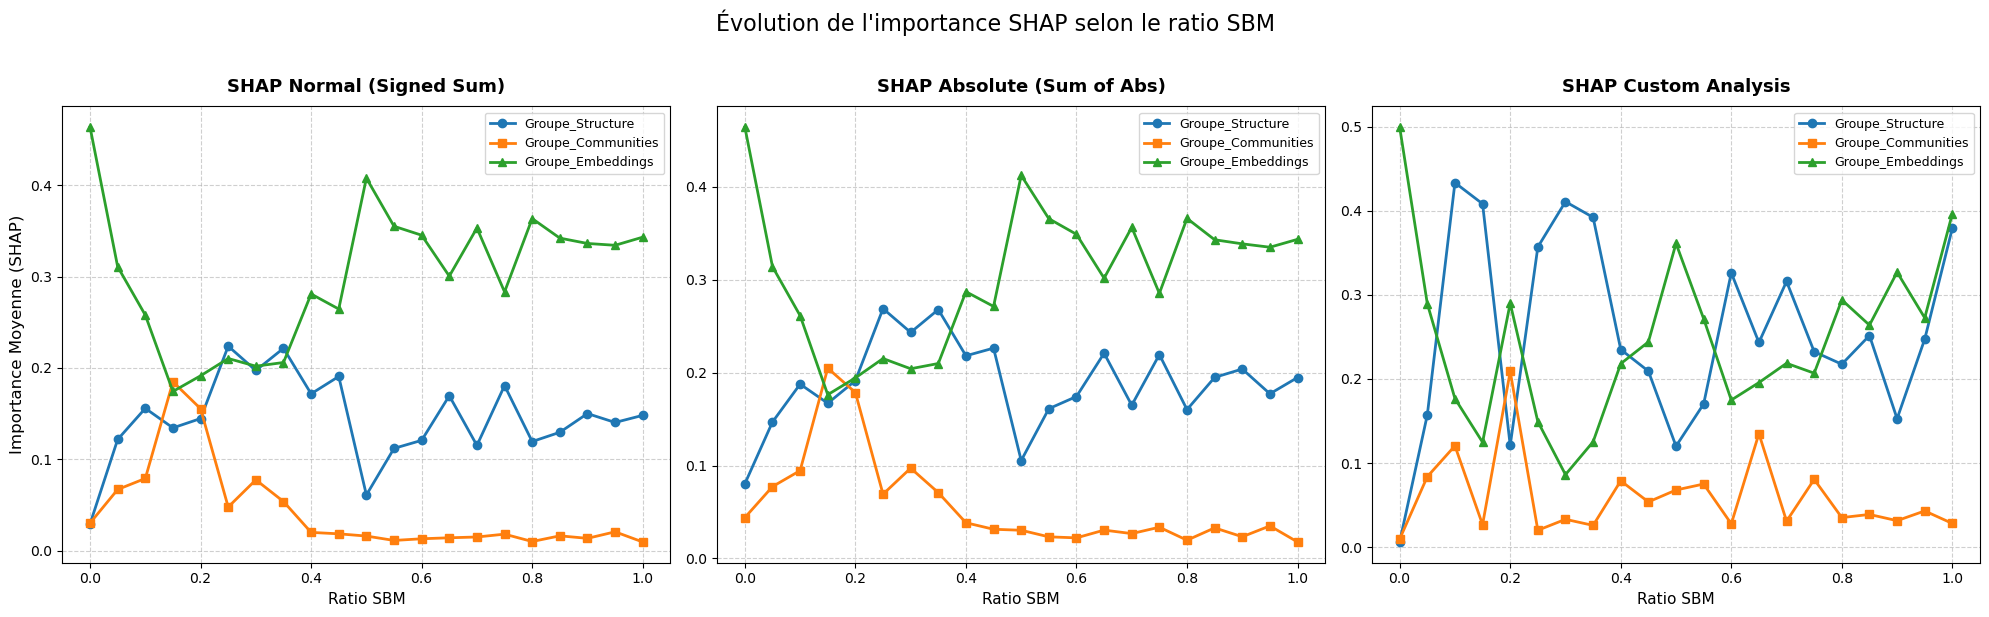

In [13]:
gp.plot_shap_evolution()

In [1]:
import node2vec
import sys

print(f"Version détectée : {node2vec.__version__}")
print(f"Emplacement physique : {node2vec.__file__}")
print("-" * 30)
print("Ordre de priorité des dossiers (sys.path) :")
for path in sys.path:
    print(path)

Version détectée : 0.5.0
Emplacement physique : /home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/node2vec/__init__.py
------------------------------
Ordre de priorité des dossiers (sys.path) :
/home/jovyan/envs/mon_env_ia/lib/python310.zip
/home/jovyan/envs/mon_env_ia/lib/python3.10
/home/jovyan/envs/mon_env_ia/lib/python3.10/lib-dynload

/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import pandas as pd
import shap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.loadsave_data_joblib(data=None, filepath = "shap_explainer.joblib", mode="load")

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

✅ Graphe chargé : 3363 nœuds et 13547 liens.


TypeError: loadsave_data_joblib() got an unexpected keyword argument 'filepath'

######################################
#### graph sbm 1.00 pos 0.00 ####
######################################
artificial_graph_sbm_1_00_pos_0_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/G_train_w_struct_com_dist_artificial_graph_sbm_1_00_pos_0_00
 Dataset chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_1_00_pos_0_00
 Taille : 38500 lignes, 33 colonnes.
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
Objet chargé avec succès depuis : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/shap_explainer_artificial_graph_sbm_1_00_pos_0_00.joblib
        u    v  deepwalk_dist  same_block_reel  block_reel_u  block_reel_v  \
3500  654  114       4.575099                0            65            11   
3501   25  

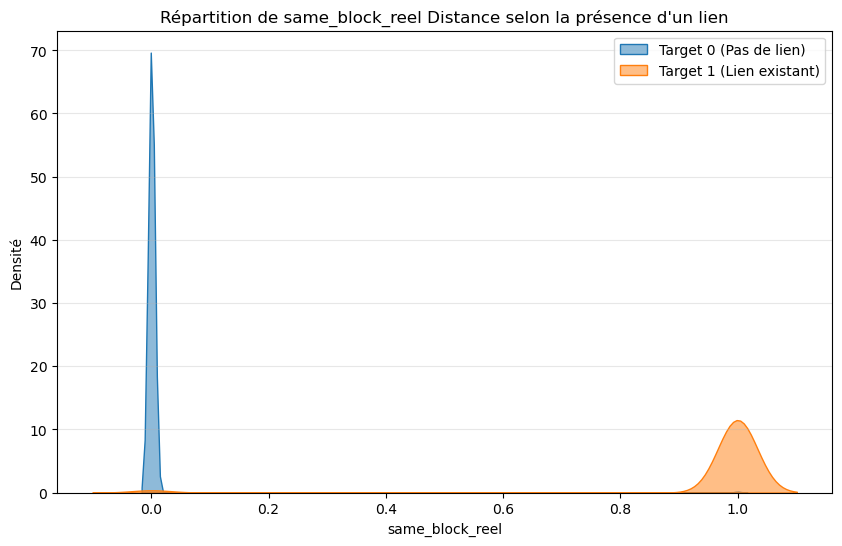

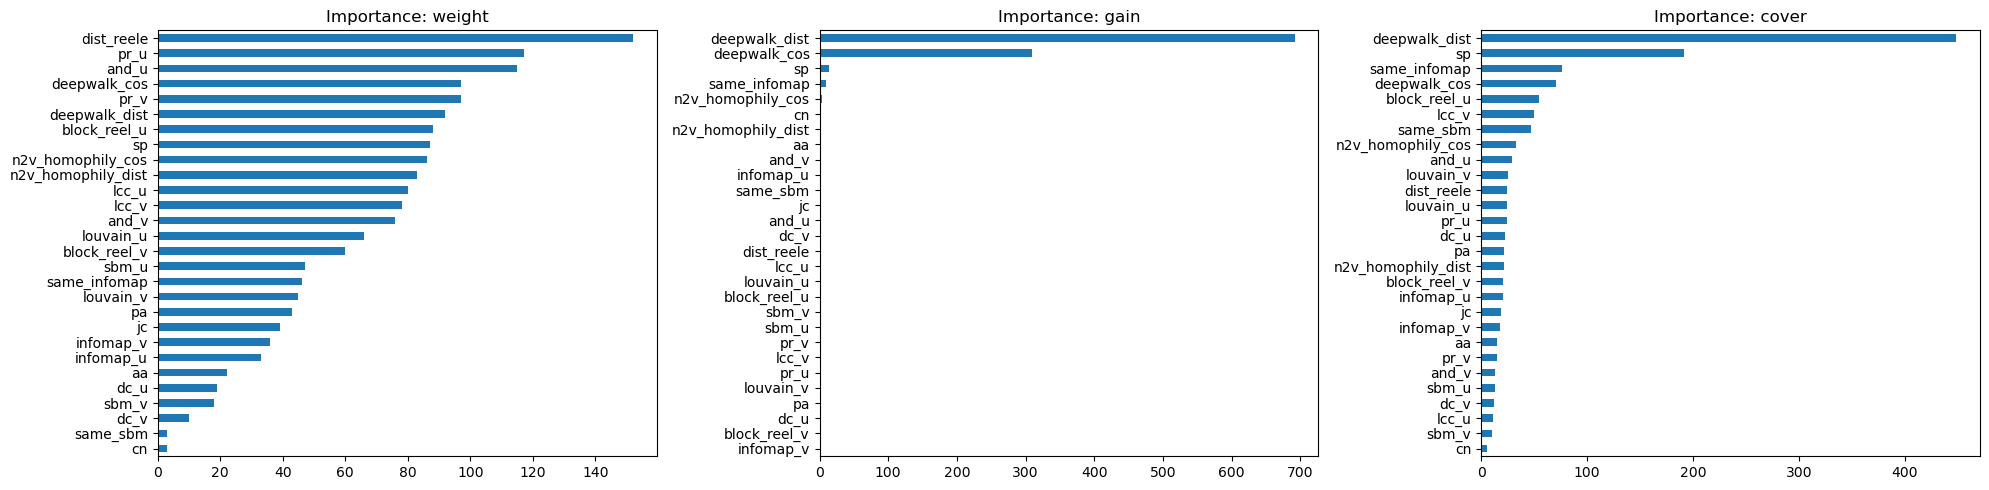

In [15]:
list_i = [1.00]

for i in list_i:
    
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")
    
    G_train, dataset_w_com_and_dist, xgboost_data, shap_explainer, shap_analysis = gp.load_all_data_for_graph(G_name)
            
    cols = ["u", "v", "deepwalk_dist", "same_block_reel", "block_reel_u", "block_reel_v", "target"]
    print(dataset_w_com_and_dist[dataset_w_com_and_dist["target"] == 0][cols].head(30))

    import matplotlib.pyplot as plt
    import seaborn as sns
    
    def plot_distributions(df, feature_name="deepwalk_dist"):
        if df is None:
            print("Erreur : Le dataset est vide.")
            return
    
        plt.figure(figsize=(10, 6))
        
        # On filtre les données pour chaque classe de target
        sns.kdeplot(data=df[df['target'] == 0], x=feature_name, label='Target 0 (Pas de lien)', fill=True, alpha=0.5)
        sns.kdeplot(data=df[df['target'] == 1], x=feature_name, label='Target 1 (Lien existant)', fill=True, alpha=0.5)
        
        plt.title(f'Répartition de {feature_name} Distance selon la présence d\'un lien')
        plt.xlabel(feature_name)
        plt.ylabel('Densité')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        
        plt.savefig(f'distrib_{feature_name}.png')
        print(f"Graphique sauvegardé sous 'distrib_{feature_name}.png'")
    
    # Appel de la fonction
    plot_distributions(dataset_w_com_and_dist, feature_name = "same_block_reel")

    correlation = dataset_w_com_and_dist['deepwalk_dist'].corr(dataset_w_com_and_dist['same_block_reel'])
    print(f"Corrélation entre DeepWalk et SameBlock: {correlation:.4f}")

    importance_types = ['weight', 'gain', 'cover']
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    model = xgboost_data['model']
    X_train = xgboost_data['X_train']
    booster = model.get_booster()
    
    for i, imp_type in enumerate(importance_types):
        scores = booster.get_score(importance_type=imp_type)
        pd.Series(scores).sort_values().plot(kind='barh', ax=axes[i], title=f'Importance: {imp_type}')
    
    plt.tight_layout()
    plt.savefig('xgboost_validation.png')

    print(dataset_w_com_and_dist["same_block_reel"].value_counts())

    # 2. Vérifiez si elle est bien dans les colonnes envoyées à XGBoost
    print("same_block_reel" in X_train.columns)
    
    # 3. Forcer l'affichage de l'importance même si elle est à zéro
    all_features = X_train.columns
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': all_features, 'Value': importances})
    print(feature_imp_df.sort_values(by='Value', ascending=False))

In [ ]:
for i in np.arange(0, 1, 0.05):
    
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")
            
    gp.execute(G,G_name)

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbm_0_00_pos_1_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.
Validation du Graphe terminée. Lancement des calculs...
Graphe original: 3500 liens
Graphe d'entraînement: 2975 liens
Liens cachés pour le test: 525
Pré-calcul des métriques de nœuds...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


DataFrame créé <3 : 38500 paires de noeuds choisies


--- Calcul des métriques de communauté ---
Calcul des communautés de louvain...
Calcul des communautés via Infomap...
Calcul des communautés via SBM...


--- Calcul des métriques de distance ---
Calcul de Node2Vec homophilie p=2, q=0.5 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:03<00:00,  6.31it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:03<00:00,  6.30it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Dataset (DataFrame) sauvegardé : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_00_pos_1_00

 RÉSULTATS
[{'F1-Score': 0.9687716863289383, 'AUC-ROC': 0.9994031558420885, 'AP': 0.9950371500636301, 'AUC-PR': 0.9950350505153359}]
Sauvegarde des données XGBoost (model,X1yTest et Train)
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_00_pos_1_00.joblib

 RÉSULTATS
 F1-Score  AUC-ROC       AP   AUC-PR
 0.968772 0.999403 0.995037 0.995035

 Shapley va ! Lu.


PermutationExplainer explainer:  23%|██▎       | 1768/7700 [02:08<08:29, 11.63it/s]

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_05_pos_0_95.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_10_pos_0_90.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_15_pos_0_85.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_20_pos_0_80.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/re

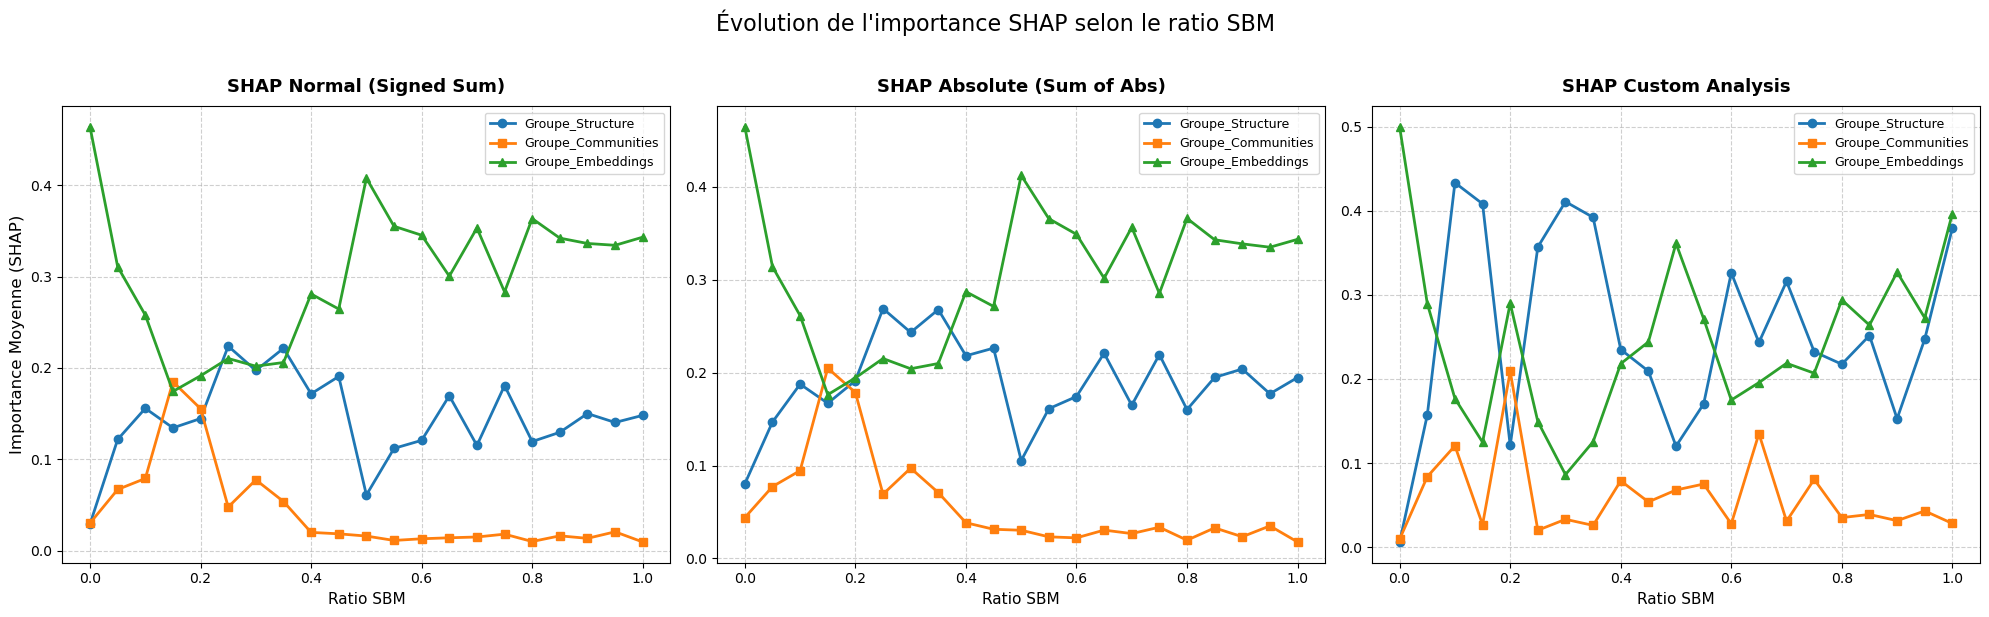

In [13]:
gp.plot_shap_evolution()

In [16]:
import node2vec
import sys

print(f"Version détectée : {node2vec.__version__}")
print(f"Emplacement physique : {node2vec.__file__}")
print("-" * 30)
print("Ordre de priorité des dossiers (sys.path) :")
for path in sys.path:
    print(path)

Version détectée : 0.5.0
Emplacement physique : /home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/node2vec/__init__.py
------------------------------
Ordre de priorité des dossiers (sys.path) :
/home/jovyan/envs/mon_env_ia/lib/python310.zip
/home/jovyan/envs/mon_env_ia/lib/python3.10
/home/jovyan/envs/mon_env_ia/lib/python3.10/lib-dynload

/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages


In [17]:
%load_ext autoreload
%autoreload 2

import src.SHAP_like_graph_tool as gp

import networkx as nx
import html
import io
import json
import numpy as np
import shap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def load_graphml_safe(path):
        with open(path, 'r', encoding='utf-8') as f:
            raw_data = f.read()

        clean_data = html.unescape(raw_data)
        G = nx.read_graphml(io.StringIO(clean_data))
        
        print(f"✅ Graphe chargé : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
        return G

G = load_graphml_safe("Airports.graphml")

## Import des shap values
shap_exp = gp.utils.loadsave_data_joblib(data=None, filepath = "shap_explainer.joblib", mode="load")

groupes = {
    "Groupe_Structure": ['cn', 'aa', 'jc', 'pa', 'sp', 'pr_u', 'pr_v', 'lcc_u', 'lcc_v', 'and_u', 'and_v', 'dc_u', 'dc_v'],
    "Groupe_Attributs": ['community_u', 'community_v', 'same_community', 'infomap_u', 'infomap_v', 'same_infomap']
}

group_indices = [
    [shap_exp.feature_names.index(f) for f in features_du_groupe]
    for features_du_groupe in groupes.values()
]

new_shap_values = np.array([
    shap_exp.values[:, indices].sum(axis=1) for indices in group_indices
]).T

new_exp = shap.Explanation(
    values=new_shap_values,
    base_values=shap_exp.base_values,
    data=None, # Les données brutes groupées (optionnel)
    feature_names=list(groupes.keys())
)

shap.plots.bar(new_exp)

print("ancienne explanation")
shap.plots.bar(shap_exp)

✅ Graphe chargé : 3363 nœuds et 13547 liens.


TypeError: loadsave_data_joblib() got an unexpected keyword argument 'filepath'

In [ ]:
for i in np.arange(0, 1, 0.05):
    
    print("######################################")
    print(f"#### graph sbm {i:.2f} pos {1-i:.2f} ####")
    print("######################################")
    G_name = f"artificial_graph_sbm_{f'{i:.2f}'.replace('.', '_')}_pos_{f'{1-i:.2f}'.replace('.', '_')}"
    print(G_name)

    with open(f"graph_library/{G_name}.json", 'r', encoding='utf-8') as f:
        data = json.load(f)  

    try:
        G = nx.node_link_graph(data)
        print(f"Graphe chargé avec succès : {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")
    except Exception as e:
        print(f"Erreur lors de la conversion : {e}")
            
    gp.execute(G,G_name)

######################################
#### graph sbm 0.00 pos 1.00 ####
######################################
artificial_graph_sbm_0_00_pos_1_00
Graphe chargé avec succès : 1000 nœuds et 3500 liens.
Validation du Graphe terminée. Lancement des calculs...
Graphe original: 3500 liens
Graphe d'entraînement: 2975 liens
Liens cachés pour le test: 525
Pré-calcul des métriques de nœuds...


/home/jovyan/envs/mon_env_ia/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


DataFrame créé <3 : 38500 paires de noeuds choisies


--- Calcul des métriques de communauté ---
Calcul des communautés de louvain...
Calcul des communautés via Infomap...
Calcul des communautés via SBM...


--- Calcul des métriques de distance ---
Calcul de Node2Vec homophilie p=2, q=0.5 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 4): 100%|██████████| 25/25 [00:03<00:00,  6.31it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


...

Generating walks (CPU: 4): 100%|██████████| 25/25 [00:04<00:00,  5.52it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Calcul de DeepWalk p=1, q=1 ...
Génération des marches aléatoires (dim=64)...


Generating walks (CPU: 2): 100%|██████████| 25/25 [00:04<00:00,  5.56it/s]


Entraînement du modèle Skip-gram...
Calcul des distances vectorielles pour chaque paire...
Dataset (DataFrame) sauvegardé : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/dataset_w_com_and_dist_artificial_graph_sbm_0_10_pos_0_90

 RÉSULTATS
[{'F1-Score': 0.96045197740113, 'AUC-ROC': 0.9882997960679348, 'AP': 0.9800314196867739, 'AUC-PR': 0.9800268502964767}]
Sauvegarde des données XGBoost (model,X1yTest et Train)
Objet sauvegardé dans : /home/jovyan/GuilhemDupuy/SHAP-like-Graph-Analysis/outputs/results/xgboost_data_artificial_graph_sbm_0_10_pos_0_90.joblib

 RÉSULTATS
 F1-Score  AUC-ROC       AP   AUC-PR
 0.960452   0.9883 0.980031 0.980027

 Shapley va ! Lu.


PermutationExplainer explainer:  59%|█████▉    | 4544/7694 [04:35<03:00, 17.41it/s]

Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_00_pos_1_00.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_05_pos_0_95.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_10_pos_0_90.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_15_pos_0_85.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/results/shap_analysis_artificial_graph_sbm_0_20_pos_0_80.joblib
Objet chargé avec succès depuis : /Users/bgdu69/Documents/Hackermann/00_StageM2/SHAP-like-Graph-Analysis/outputs/re

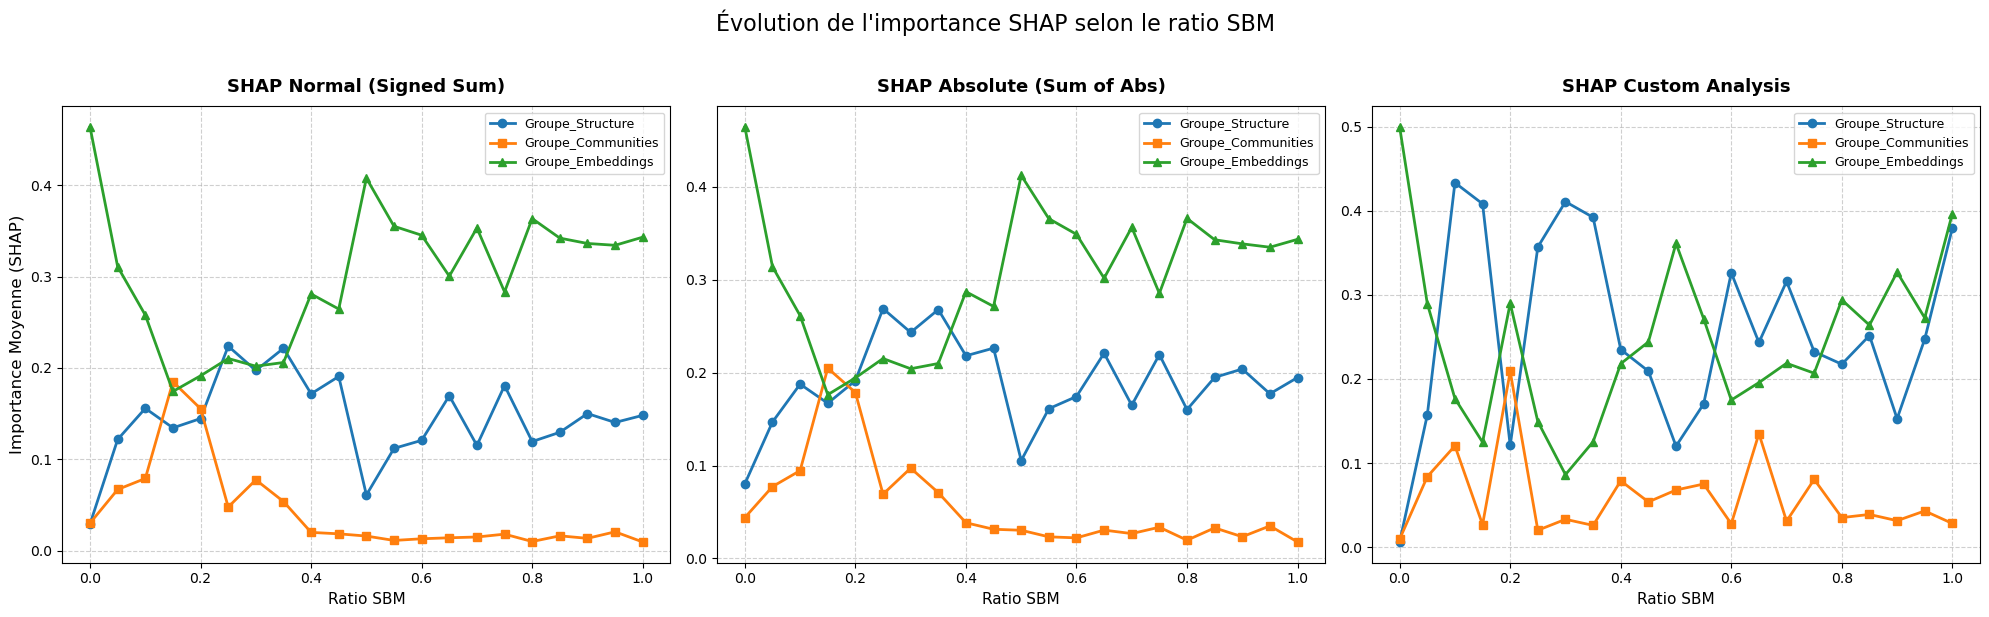

In [13]:
gp.plot_shap_evolution()